# Classify New Samples

In [5]:
import csv

def load_play_ball(path):
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        rows = []
        for row in reader:
            cleaned = {key.strip(): value.strip() for key, value in row.items()}
            rows.append(cleaned)
    return rows

data = load_play_ball("/kaggle/input/datasets/enigmatronix13/playball/dataset.csv")
target = "Play ball"
features = [key for key in data[0].keys() if key not in ("Day", target)]

In [6]:
rules = [
    ("Outlook=Overcast", "Yes"),
    ("Outlook=Rain and Wind=Strong", "No"),
    ("Outlook=Rain and Wind=Weak", "Yes"),
    ("Outlook=Sunny and Humidity=High", "No"),
    ("Outlook=Sunny and Humidity=Normal", "Yes"),
]

def classify_with_rules(rules, sample, default=None):
    for condition, label in rules:
        parts = condition.split(" and ")
        match = True
        for part in parts:
            feature, value = part.split("=")
            if sample.get(feature) != value:
                match = False
                break
        if match:
            return label
    return default

for condition, label in rules:
    print(f"IF {condition} THEN Play ball={label}")

IF Outlook=Overcast THEN Play ball=Yes
IF Outlook=Rain and Wind=Strong THEN Play ball=No
IF Outlook=Rain and Wind=Weak THEN Play ball=Yes
IF Outlook=Sunny and Humidity=High THEN Play ball=No
IF Outlook=Sunny and Humidity=Normal THEN Play ball=Yes


In [7]:
new_samples = [
    {"Outlook": "Sunny", "Temperature": "Cool", "Humidity": "High", "Wind": "Strong"},
    {"Outlook": "Rain", "Temperature": "Mild", "Humidity": "Normal", "Wind": "Weak"},
    {"Outlook": "Overcast", "Temperature": "Hot", "Humidity": "High", "Wind": "Weak"}
]

predictions = []
for i, sample in enumerate(new_samples, start=1):
    pred = classify_with_rules(rules, sample, default="Yes")
    predictions.append(pred)
    print(f"Sample {i}: {sample} -> Play ball={pred}")

Sample 1: {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'} -> Play ball=No
Sample 2: {'Outlook': 'Rain', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak'} -> Play ball=Yes
Sample 3: {'Outlook': 'Overcast', 'Temperature': 'Hot', 'Humidity': 'High', 'Wind': 'Weak'} -> Play ball=Yes


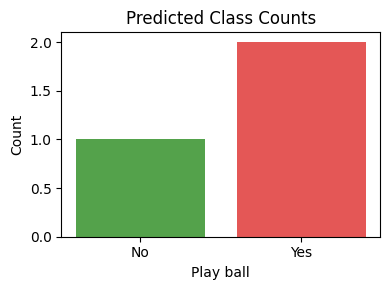

In [8]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(predictions)
labels = list(counts.keys())
values = [counts[label] for label in labels]

plt.figure(figsize=(4, 3))
plt.bar(labels, values, color=["#54A24B", "#E45756"])
plt.title("Predicted Class Counts")
plt.xlabel("Play ball")
plt.ylabel("Count")
plt.tight_layout()
plt.show()